# Task Intro

In this exercise, we will use a Hierarchical reinforcement learning (HRL) model performing a reversal learning task (Rmus
et al., 2024). In this task, participants observe three colored arrows, each pointing left or right (Fig A). To earn rewards, participants choose a direction (left/right) based on the correct colored arrow/rule. The correct arrow changes unpredictably, which means that participants must keep track of which arrow most reliably leads to the reward, and update accordingly when the change occurs (Fig B). This task is hierarchical because the correct choice (left/right) depends on a higher-level rule tied to arrow color (Fig C).

Reference
* Rmus M, Pan T-F, Xia L, Collins AGE. Artificial neural networks for model identification and parameter estimation in computational cognitive models. PLoS Comput Biol (2024): [link](https://doi.org/10.1371/journal.pcbi.1012119)
* Pan, TF., Li, JJ., Thompson, B, Collins AGE. Latent variable sequence identification for cognitive models with neural network estimators. Behav Res 57, 272 (2025). [link](https://doi.org/10.3758/s13428-025-02794-0)


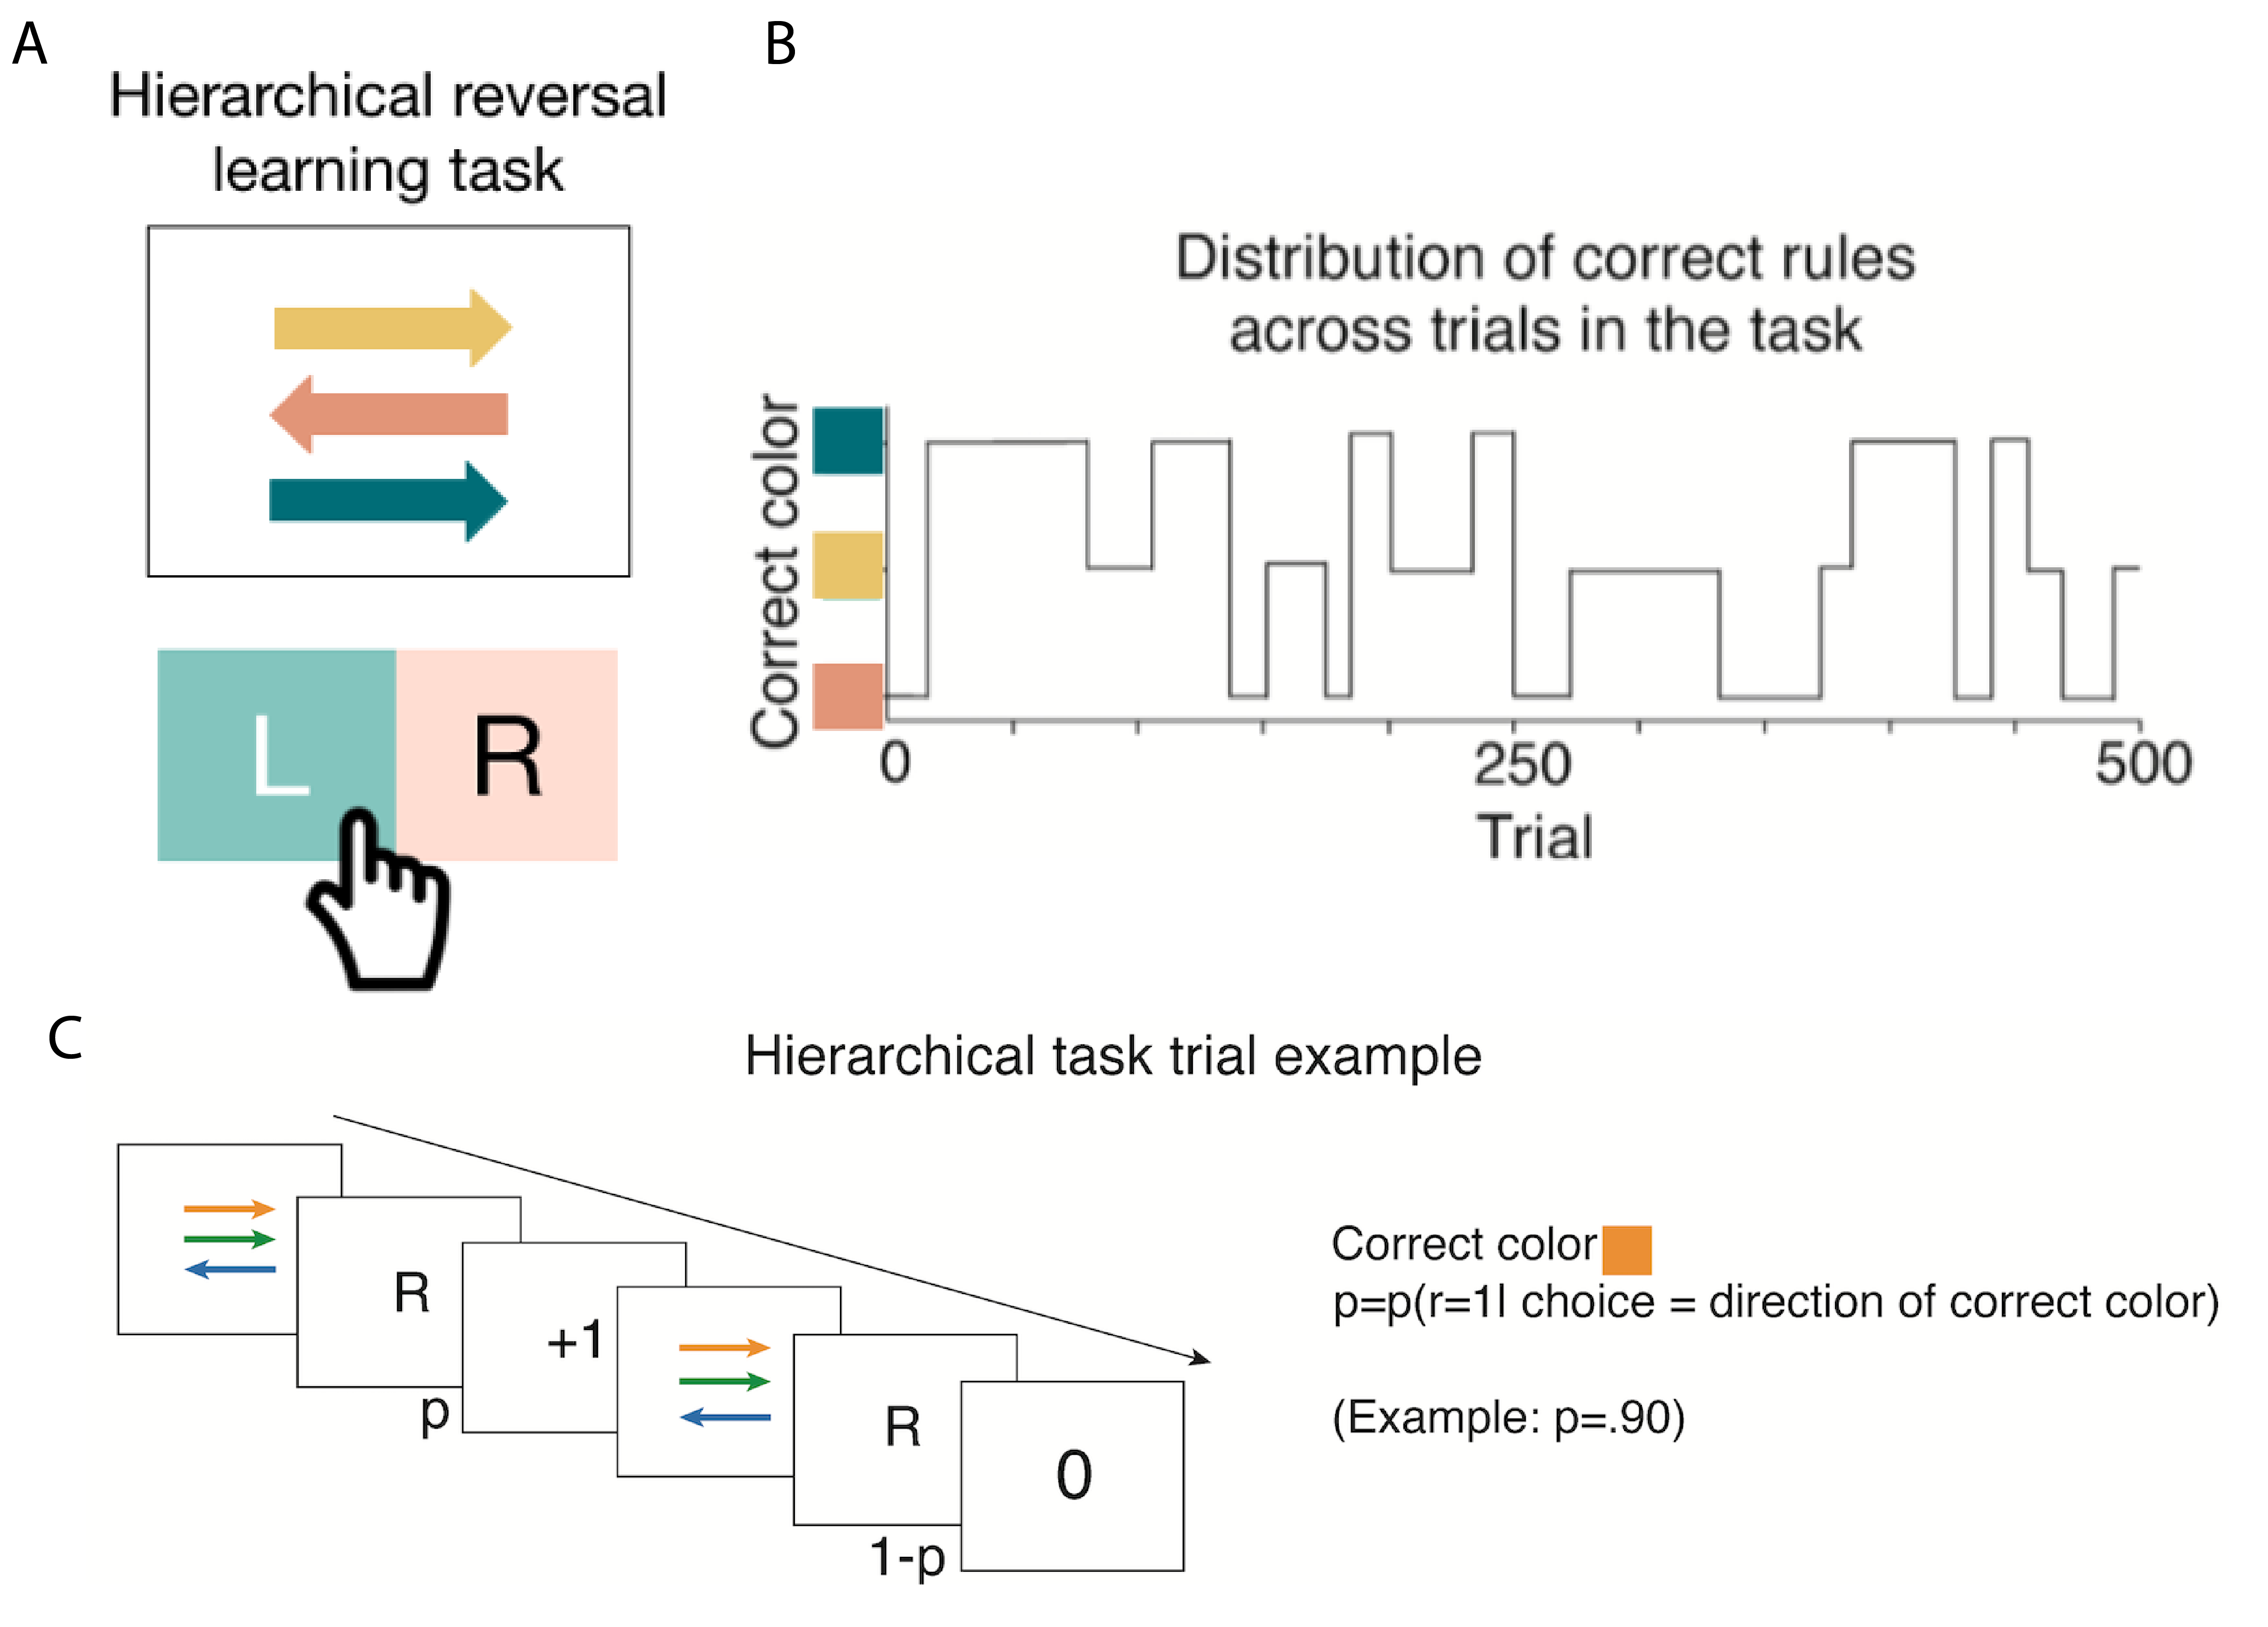

# Setup

In [1]:
!rm -rf lasenet # clear up dir if any
!git clone https://github.com/ti55987/lasenet

%cd lasenet

Cloning into 'lasenet'...
remote: Enumerating objects: 116, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 116 (delta 1), reused 8 (delta 1), pack-reused 108 (from 1)
Receiving objects: 100% (116/116), 3.48 MiB | 7.18 MiB/s, done.
Resolving deltas: 100% (43/43), done.
/content/lasenet


In [2]:
import pandas as pd
import numpy as np
import time
import tqdm
import random
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    Bidirectional,
    GRU,
)
from tensorflow.keras.optimizers import Adam
from keras.callbacks import EarlyStopping

tf.keras.utils.set_random_seed(11)
tf.config.experimental.enable_op_determinism()

from utils.feature_utils import (
    get_onehot_features,
    get_latent_labels,
    CognitiveModel,
    get_labels_by_model
)
from utils.training_utils import set_seed

from training.models import create_model

#Hierarchical Reinforcement Learning (HRL) Model

We assume that agents use a simple reinforcement learning (RL) process to track arrow values and select a discrete arrow, before deciding on a side. Under these assumptions, the model is intractable, because the internal “arrow rule” selected by agents is unobservable and conditions on Q-value updates.

1) choose an arroow based on policy (N = number of arrows):
$$P(\text{arrow}_i) = \frac{\exp(\beta \cdot Q_t(\text{arrow}_i))}{\sum_{j = 1}^{N} \exp(\beta \cdot Q_t(\text{arrow}_j))}$$

2) update chosen Q values based on received outcome ($r_t$ = 1 or 0).
$$
\begin{gathered}
\delta_t = r_t - Q_t(\text{arrow}_i) \\
Q_{t+1}(\text{arrow}_i)=Q_t(\text{arrow}_i) + \alpha\,\delta_t
\end{gathered}
$$

3) counterfactual update
$$
\begin{gathered}
\delta_\text{unchosen} = (1-r) - Q_t(\text{other_arrow}_i) \\
Q_{t+1}(\text{other_arrow}_i) = Q_t(\text{other_arrow}_i) + \alpha \cdot \delta_\text{unchosen}
\end{gathered}
$$



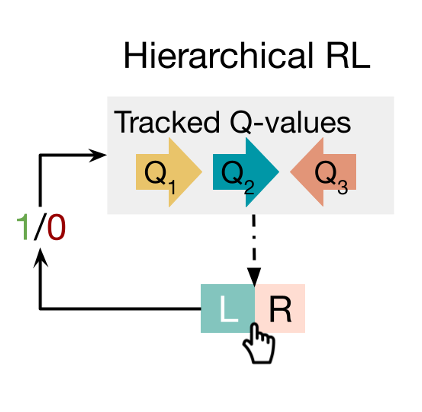

In [3]:
from scipy.special import softmax

def simulate_hrl(agent_id, parameters, num_trials, p_val=[0.1, 0.9], p_switch=0.05, num_bandits=3):
    """
    Simulates a Hierarchical Reinforcement Learning agent in a multi-armed bandit task
    with counterfactual updating, stickiness, and rule switching.

    Args:
        parameters (list or tuple): A 4-element sequence containing:
            - softmax_beta (float): Inverse temperature for the softmax action selection. Higher = more deterministic.
            - learning_rate (float): The step size for updating Q-values (alpha).
            - stickiness (float): A scalar added to the previously chosen cue's Q-value to model choice perseveration.
            - epsilon (float): The probability of a random motor slip (executing the opposite of the intended action).
        num_trials (int): The total number of trials to simulate.
        p_val (list or tuple): Reward probabilities mapped to correctness.
            Format: [prob_reward_if_incorrect, prob_reward_if_correct].
        p_switch (float): The probability of the valid rule (correct cue) switching on a given trial,
            evaluated only after a rule has been active for >10 trials.
        num_bandits (int): The number of available cues/bandits the agent can choose from.
        agent_id (int or str): A unique identifier for the simulated agent.

    Returns:
        pd.DataFrame: A trial-by-trial record of the simulation containing the following key columns:
            - agent_id, trials: The agent identifier and the trial index.
            - alpha, beta, stickiness: The model parameters.
            - stimulus_0, stimulus_1, stimulus_2: The binary direction (e.g., pointing left/right) of the stimuli.
            - chosen_cue: The index (0 to 2) of the bandit selected by the agent.
            - chosen_side: The actual binary side/motor action executed (incorporating epsilon slips).
            - correct_cue: The index of the currently valid rule/bandit.
            - is_correct_cue: Boolean (1 or 0) indicating if the chosen side matched the correct cue's side.
            - rewards: The binary reward received (1 or 0).
            - chosen_qv: The Q-value of the selected cue before the update.
            - rpe_history: The Reward Prediction Error (RPE) generated on that trial.
            - is_switch: Boolean (1 or 0) flagging if the underlying rule switched on that trial.
            - correct_rule_iteration: Counter of how many trials the current rule has been active.
            - qv_0, qv_1, qv_2: The tracked Q-values for each individual bandit.
    """

    # 1. Unpack parameters
    softmax_beta, learning_rate, stickiness, epsilon = parameters

    # 2. Initialize Q-values (flat prior) and tracking variables
    Q = np.full(num_bandits, 1.0 / num_bandits)
    rule_step = 0
    correct_cue = 1
    chosen_cue = None  # Tracks the previous choice to apply stickiness

    # 3. Prepare stimuli (repeat base matrix to fit num_trials, then shuffle)
    base_stims = np.array([[0, 1, 0], [1, 0, 1], [0, 0, 1], [0, 1, 1], [1, 0, 0]])
    repeats = int(np.ceil(num_trials / len(base_stims)))
    stims = np.repeat(base_stims, repeats, axis=0)[:num_trials]
    np.random.shuffle(stims)

    # 4. Pre-allocate data dictionary for efficiency
    data = {
        "agentid": [agent_id] * num_trials,
        "trials": np.arange(num_trials),
        "alpha": [learning_rate] * num_trials,
        "beta": [softmax_beta] * num_trials,
        "stickiness": [stickiness] * num_trials,
        "stimulus_0": stims[:, 0],
        "stimulus_1": stims[:, 1],
        "stimulus_2": stims[:, 2],
        "is_switch": np.zeros(num_trials, dtype=int),
        "correct_cue": [], "rewards": [], "is_correct_cue": [],
        "rpe_history": [], "chosen_qv": [], "chosen_side": [],
        "chosen_cue": [], "correct_rule_iteration": []
    }
    for nb in range(num_bandits):
        data[f"qv_{nb}"] = []

    # 5. Run simulation loop
    for t, stim in enumerate(stims):
        # Record current Q-values
        for nb in range(num_bandits):
            data[f"qv_{nb}"].append(Q[nb])

        # Apply stickiness to the previous choice's Q-value for softmax evaluation
        W = Q.copy()
        if chosen_cue is not None:
            W[chosen_cue] += stickiness

        # Action selection via Softmax
        probs = softmax(softmax_beta * W)
        chosen_cue = np.random.choice(num_bandits, p=probs)

        # Determine selected side (apply epsilon-greedy noise/slip)
        intended_side = stim[chosen_cue]
        side = 1 - intended_side if np.random.rand() < epsilon else intended_side

        # Evaluate response: Does the chosen side match the side of the currently valid cue?
        is_correct_side = int(side == stim[correct_cue])

        # Generate reward based on probability profile
        reward = int(np.random.rand() < p_val[is_correct_side])

        # Calculate Reward Prediction Error (RPE)
        rpe = reward - Q[chosen_cue]
        data["chosen_qv"].append(Q[chosen_cue])

        # Factual update: update the Q-value for the chosen cue
        Q[chosen_cue] += learning_rate * rpe

        # Counterfactual update: update Q-values for unchosen cues assuming outcome (1 - reward)
        unchosen_mask = np.arange(num_bandits) != chosen_cue
        Q[unchosen_mask] += learning_rate * ((1 - reward) - Q[unchosen_mask])

        # Store trial-level data
        data["correct_cue"].append(correct_cue)
        data["correct_rule_iteration"].append(rule_step)
        data["chosen_cue"].append(chosen_cue)
        data["chosen_side"].append(side)
        data["is_correct_cue"].append(is_correct_side)
        data["rewards"].append(reward)
        data["rpe_history"].append(rpe)

        # Rule switch logic: after 10 iterations on a rule, probabilistic switch
        if rule_step > 10 and np.random.rand() < p_switch:
            rule_step = 1
            available_cues = np.delete(np.arange(num_bandits), correct_cue)
            correct_cue = np.random.choice(available_cues)
            if t < num_trials - 1:
                data["is_switch"][t + 1] = 1
        else:
            rule_step += 1

    return pd.DataFrame(data)

# Prepare training and test data for LaseNet

Let's generate simulation data from the HRL model. In this exercise, we only generate 100 agents for demonstration in order to run on CPU.  In practice, it's good to start with 3000 agents ,and bump up the number of agents if necessary. In LaseNet paper (Pan et al 2025), we found 9000 agents usually give you a good recovery performance.

In [10]:
N_AGENTS = 100
num_trials = 720

data_list = []
for a in tqdm.tqdm(range(N_AGENTS)):
    # simulate N_AGENTS agents with randomly sampled alphas and betas
    rand_alpha = random.uniform(0.4, 0.7)
    rand_beta = random.uniform(1, 10)
    # Fixed stickiness to 0
    parameters = [rand_beta, rand_alpha, 0, 0]
    data = simulate_hrl(a, parameters, num_trials)
    data_list.append(data)

data_df = pd.concat(data_list)
data_df.head(3)

100%|██████████| 100/100 [00:06<00:00, 14.94it/s]


,agentid,trials,alpha,beta,stickiness,stimulus_0,stimulus_1,stimulus_2,is_switch,correct_cue,rewards,is_correct_cue,rpe_history,chosen_qv,chosen_side,chosen_cue,correct_rule_iteration,qv_0,qv_1,qv_2
0,0,0,0.434388,9.450429,0,0,0,1,0,1,0,0,-0.333333,0.333333,1,2,0,0.333333,0.333333,0.333333
1,0,1,0.434388,9.450429,0,0,1,0,0,1,0,0,-0.622925,0.622925,0,0,1,0.622925,0.622925,0.188537
2,0,2,0.434388,9.450429,0,1,0,1,0,1,1,1,0.213278,0.786722,0,1,2,0.352334,0.786722,0.541027


## Sanity check for simulation data

Before training the LaseNet, it is important to validate our simulation data that align with the behaviors.

In [5]:
from utils.behavior_utils import analyze_switch

num_pre_switch_trials = 4  # number of trials before the switch
num_post_switch_trials = 8  # number of trials after the switch

# Get unique agent IDs (updated to 'agent_id' to match previous DataFrame refactoring)
all_sims = data_df['agentid'].unique()
num_sims_to_plot = 50

# Initialize a NaN array using np.full (cleaner than np.nan * np.ones)
window_size = num_pre_switch_trials + num_post_switch_trials
all_learning_curves = np.full((num_sims_to_plot, window_size), np.nan)

# Loop through the subset of agents and calculate their switch learning curves
for i in range(num_sims_to_plot):
    # Extract data for the specific agent
    agent_data = data_df[data_df['agentid'] == all_sims[i]]

    # Calculate the learning curve using the newly refactored function
    all_learning_curves[i] = analyze_switch(
        agent_data,
        num_pre_switch_trials,
        num_post_switch_trials
    )

print(f'number agents: {all_learning_curves.shape[0]}, number of trials: {all_learning_curves.shape[1]}')

number agents: 50, number of trials: 12


Let's visualize the learning curves. What do you observe? Is it aligned with your expectations from a reversal learning task?

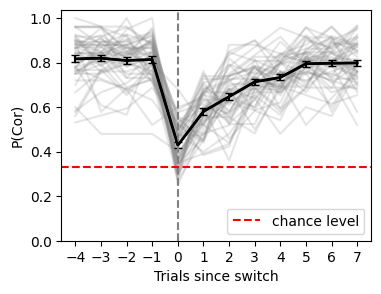

In [ ]:
# Calculate the mean across the entire sample (axis=0 averages vertically across agents)
mean_learning_curve = np.nanmean(all_learning_curves, axis=0)

# Calculate the Standard Error of the Mean (SEM)
num_plotted_sims = all_learning_curves.shape[0]
sem_learning_curve = np.nanstd(all_learning_curves, axis=0) / np.sqrt(num_plotted_sims)

# For the x-axis: trials before and after the switch (e.g., -4 to 9)
trials_since_switch = np.arange(-num_pre_switch_trials, num_post_switch_trials)

# Initialize the plot using standard matplotlib naming (fig, ax)
fig, ax = plt.subplots(figsize=(4, 3))

# Plot individual agent learning curves
for curve in all_learning_curves:
    # --- Optional B-Spline smoothing block ---
    # x_new = np.linspace(1, len(trials_since_switch), 50)
    # curve_b_spline = interpolate.make_interp_spline(np.arange(len(trials_since_switch)) + 1, curve)
    # y_new = curve_b_spline(x_new)
    # -----------------------------------------

    # Adding alpha=0.2 makes the individual lines slightly transparent
    # so the black average line stands out better on top of them.
    ax.plot(trials_since_switch, curve, color='grey', alpha=0.2)

# Plot the sample average and add error bars
ax.plot(trials_since_switch, mean_learning_curve, color='black', linewidth=2)
ax.errorbar(
    trials_since_switch,
    mean_learning_curve,
    yerr=sem_learning_curve,
    color='black',
    capsize=3  # Adds little horizontal caps to the error bars for readability
)

# Format the axes
ax.set_xlabel('Trials since switch')
ax.set_xticks(trials_since_switch)
ax.set_ylabel('P(Cor)')
ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.axvline(x=0, color='grey', linestyle='--')
ax.axhline(y=1/3, label='chance level', color='red', linestyle='--')
ax.legend()

plt.show()

# (TODO) Extract features and labels

After generating the data, it's time to extract important features and labels for LaseNet.  Now, discuss with your neighbors to figure out:
1) What are the observable features to extract for input?
2) What are the unobservable discrete and continuous latent variable to infer?

The available columns in the generated simulation data:
- agentid, trials: The agent identifier and the trial index.
- alpha, beta, stickiness: The model parameters of an agent.
- stimulus_0, stimulus_1, stimulus_2: The binary direction (e.g., pointing left/right) of the stimuli.
- chosen_cue: The index (0 to 2) of the arrow selected by the agent.
- chosen_side: The binary side chosen by a agent.
- correct_cue: The index of the currently valid rule/cue.
- is_correct_cue: Boolean (1 or 0) indicating if the chosen side matched the correct cue's side.
- rewards: The reward received (1 or 0).
- chosen_qv: The Q-value of the selected cue before the update.
- rpe_history: The Reward Prediction Error (RPE) generated on that trial.
- is_switch: Boolean (1 or 0) flagging if the underlying rule switched on that trial.
- correct_rule_iteration: Counter of how many trials the current rule has been active.
- qv_0, qv_1, qv_2: The tracked Q-values for each individual cue.

In [11]:
# extract input features
############## FILL ME IN
feature_list = []
target_discrete_param = ''
target_cont_param = ''
##############

features = get_onehot_features(data_df, feature_list)

# extract labels for supervised learning
# discrete label
discrete_labels = get_latent_labels(data_df, target_discrete_param)
n_cue = data_df[target_discrete_param].nunique()
normalized_discrete_labels = tf.keras.utils.to_categorical(discrete_labels, num_classes=n_cue)

# continuous label
qv = get_latent_labels(data_df, target_cont_param)
n_agent, n_trial = data_df.agentid.nunique(), data_df.trials.nunique()
cont_labels = qv.astype(np.float32).reshape((n_agent, n_trial))

# Train validation(test) split
X_train, X_test, discrete_train, discrete_test, cont_train, cont_test = train_test_split(
    features.numpy(),
    normalized_discrete_labels,
    cont_labels,
    test_size=0.1,
    random_state=33,
)

print(
    X_train.shape,
    X_test.shape,
    discrete_train.shape,
    discrete_test.shape,
    cont_train.shape,
    cont_test.shape,
)

(90, 720, 10) (10, 720, 10) (90, 720, 3) (10, 720, 3) (90, 720) (10, 720)


# LaseNet Training

Now, let's define our hyper-parameters and loss function. You don't need to change the hyper-parameters for this exercise. In practice, you could finetune the hyperparameters. The code is provided in the last section ***(optional) Finetune hyperparameters***

In [18]:
set_seed(33)
############## LaseNet parameters
batch_size = 24
units = 12
dropout = 0.19963
dropout1 = 0.053
dropout2 =  0.0497
learning_rate = 3e-3
###############

n_agents, n_trial = features.shape[0], features.shape[1]
identifier = f'A{n_agents}_{n_trial}t_B{batch_size}_U{units}_D{dropout}_D{dropout1}_D{dropout2}'
print(identifier)

lasenet = create_model(
    feature_dim=X_train.shape[-1],
    continuous_output_dim=1,
    discrete_output_dim=discrete_train.shape[-1],
    units=units,
    dropout=dropout,
    dropout1=dropout1,
    dropout2=dropout2,
)

optimizer = Adam(learning_rate=learning_rate)
lasenet.compile(
    loss={
        "discrete_latent": "categorical_crossentropy",
        "continuous_latent": "mse",
    },
    loss_weights={"discrete_latent": 0.25, "continuous_latent": 1},
    optimizer=optimizer,
)

Random seed set as 33
A3000_720t_B128_U193_D0.07_D0.053_D0.014


Here, we set epochs to 100 for demonstration. In practice, you could bump up to 300 or more.

In [19]:
callbacks = [EarlyStopping(monitor="val_loss", patience=35, restore_best_weights=True)]
start = time.time()

history = lasenet.fit(
    X_train,
    y={"discrete_latent": discrete_train, "continuous_latent": cont_train},
    batch_size=batch_size,
    epochs=100,
    verbose=2,
    callbacks=callbacks,
    validation_data=(X_test, {"discrete_latent": discrete_test, "continuous_latent": cont_test}),
)

end = time.time()
print(end - start)

Epoch 1/100
22/22 - 5s - 223ms/step - continuous_latent_loss: 0.1256 - discrete_latent_loss: 1.0938 - loss: 0.4031 - val_continuous_latent_loss: 0.0505 - val_discrete_latent_loss: 1.0755 - val_loss: 0.3190
Epoch 2/100
22/22 - 2s - 77ms/step - continuous_latent_loss: 0.0506 - discrete_latent_loss: 1.0449 - loss: 0.3132 - val_continuous_latent_loss: 0.0488 - val_discrete_latent_loss: 0.9707 - val_loss: 0.2912
Epoch 3/100
22/22 - 2s - 78ms/step - continuous_latent_loss: 0.0500 - discrete_latent_loss: 0.8242 - loss: 0.2588 - val_continuous_latent_loss: 0.0507 - val_discrete_latent_loss: 0.5986 - val_loss: 0.2001
Epoch 4/100
22/22 - 2s - 78ms/step - continuous_latent_loss: 0.0512 - discrete_latent_loss: 0.4856 - loss: 0.1747 - val_continuous_latent_loss: 0.0472 - val_discrete_latent_loss: 0.3421 - val_loss: 0.1323
Epoch 5/100
22/22 - 2s - 78ms/step - continuous_latent_loss: 0.0493 - discrete_latent_loss: 0.3295 - loss: 0.1330 - val_continuous_latent_loss: 0.0444 - val_discrete_latent_loss: 

Run the cell below to check your training and validation loss.  Do they both decrease over epochs?

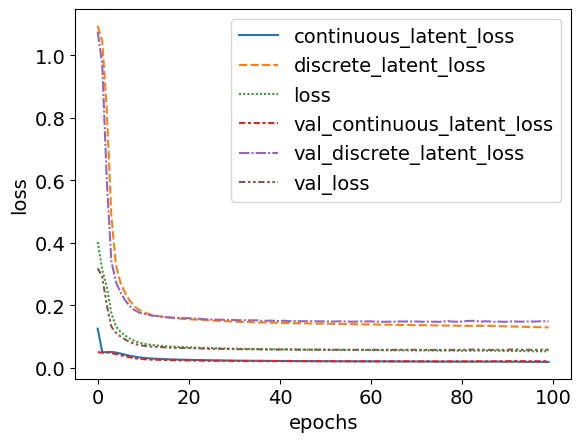

In [40]:
result = pd.DataFrame(history.history)
ax = sns.lineplot(result)
ax.set_xlabel('epochs')
ax.set_ylabel('loss')

# Comment me out if you want to save the model
#lasenet.save(f'lasenet_{identifier}_model.keras')

# Evaluation

Before using LaseNet to infer your experimental data, we need to validate if LaseNet can generalize to unseen dataset. In the cell below, we will generate another dataset for evaluation.

In [5]:
#@title Generate test data

n_test_agents = 50
num_trials = 720

data_list = []
for a in tqdm.tqdm(range(n_test_agents)):
    # simulate N_AGENTS agents with randomly sampled alphas and betas
    rand_alpha = random.uniform(0.4, 0.7)
    rand_beta = random.uniform(1, 10)
    # Fixed stickiness to 0
    parameters = [rand_beta, rand_alpha, 0, 0]
    data = simulate_hrl(a, parameters, num_trials)
    data_list.append(data)

test_df = pd.concat(data_list)
test_df.head(3)

100%|██████████| 500/500 [00:49<00:00, 10.20it/s]


,agentid,trials,alpha,beta,stickiness,stimulus_0,stimulus_1,stimulus_2,is_switch,correct_cue,rewards,is_correct_cue,rpe_history,chosen_qv,chosen_side,chosen_cue,correct_rule_iteration,qv_0,qv_1,qv_2
0,0,0,0.535714,6.037951,0,0,1,0,0,1,0,0,-0.333333,0.333333,0,2,0,0.333333,0.333333,0.333333
1,0,1,0.535714,6.037951,0,0,1,0,0,1,0,0,-0.690476,0.690476,0,0,1,0.690476,0.690476,0.154762
2,0,2,0.535714,6.037951,0,1,0,0,0,1,0,1,-0.856292,0.856292,0,1,2,0.320578,0.856292,0.607568


To evaluate the recovery performance of a well-trained network, we will load a pre-trained LaseNet configuration optimized with 3,000 agents.

In [6]:
# Loading a trained lasenet with 3000 agents 720 trials
model_path = './tutorial/lasenet_A3000_720t_B128_U193_D0.07_D0.053_D0.014_model.keras'
lasenet = tf.keras.models.load_model(model_path)
# extract test features
test_features = get_onehot_features(test_df, feature_list)
# model predicition
lasenet_pred_discrete, lasenet_pred_cont = lasenet.predict(test_features)
lasenet_pred_cont = np.squeeze(lasenet_pred_cont, axis=-1)
print(lasenet_pred_discrete.shape, lasenet_pred_cont.shape)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step
(500, 720, 3) (500, 720)


Now, let’s compare the predicted latent variables with the ground-truth latent variables on the simulated test data. Discuss with your neighbors why the predictions may be less accurate for certain trials and consider the potential factors that could contribute to these discrepancies.

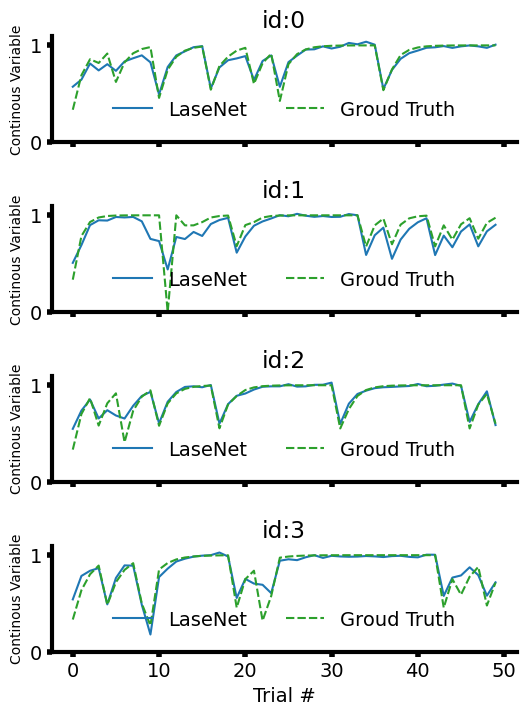

In [8]:
# Evaluate the continuous latent variable inference
true_label = test_df[target_cont_param].to_numpy().reshape((n_test_agents, num_trials))
nrows, n_cols = 4, 1
fig, axes = plt.subplots(nrows=nrows, ncols=n_cols, figsize=(n_cols*6, nrows*2), sharey=True, sharex=True)

plt.rcParams.update({'font.size': 14})
line_color = {'LaseNet': sns.color_palette()[0], 'Groud Truth': sns.color_palette()[2]}
max_trial = 50
for agent_idx in range(nrows):
  result = {
      'LaseNet': lasenet_pred_cont[agent_idx][:max_trial],
      'Groud Truth': true_label[agent_idx][:max_trial],
  }
  ax = sns.lineplot(result, ax=axes[agent_idx], palette=line_color)
  sns.move_legend(
    ax, "lower center",
    bbox_to_anchor=(0.5, 0.05), ncol=len(result), title=None, frameon=False,
  )
  ax.set_xlabel('Trial #')
  ax.set_title(f'id:{agent_idx}')
  ax.set_ylim(0, 1.1)

  for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(3)
  # increase tick width
  ax.tick_params(width=4)
  ax.set_ylabel('Continous Variable', color='black', size=10)

fig.subplots_adjust(
    hspace=0.6,   # vertical gap
)
sns.despine()


Text(0.5, 1.0, 'HRL')

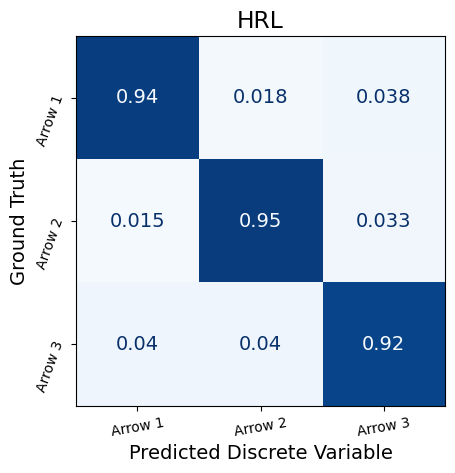

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay

# Evaluate the discrete latent variable inference
plt.rcParams.update({'font.size': 14})
target_names = ['Arrow 1', 'Arrow 2', 'Arrow 3']
true_latent = test_df[target_discrete_param].to_numpy()
pred_latent = np.argmax(lasenet_pred_discrete, axis=2)

disp = ConfusionMatrixDisplay.from_predictions(
    true_latent,
    pred_latent.ravel(),
    display_labels=target_names,
    cmap=plt.cm.Blues,
    colorbar=False,
    normalize='true')
# Set the fixed color bar range
disp.im_.set_clim(0, 1)
disp.ax_.tick_params(axis='both', which='major', labelsize=10)
plt.setp(disp.ax_.get_yticklabels(), rotation=70)
plt.setp(disp.ax_.get_xticklabels(), rotation=10)
disp.ax_.set_xlabel('Predicted Discrete Variable')
disp.ax_.set_ylabel('Ground Truth')
disp.ax_.set_title('HRL')

# (optional) Finetune hyperparameters

This is a framework you can use to fine-tune your hyperparameters in LaseNet.

In [ ]:
#@title Setup
!pip install --upgrade keras-hypetune
!pip install -q -U keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 966.0/966.0 kB 18.8 MB/s eta 0:00:00
  Attempting uninstall: hyperopt
    Found existing installation: hyperopt 0.2.7
    Uninstalling hyperopt-0.2.7:
      Successfully uninstalled hyperopt-0.2.7
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.4 MB/s eta 0:00:00


In [ ]:
from kerashypetune import KerasBayesianSearch
from hyperopt import hp, Trials

def get_model(parms):
  lasenet = create_model(
      parms["feature_dim"],
      parms["discrete_output_dim"],
      parms["continuous_output_dim"],
      parms["units"],
      parms["dropout"],
      parms["dropout1"],
      parms["dropout2"],
  )
  optimizer = Adam(learning_rate=parms["learning_rate"])
  lasenet.compile(
      loss={
          "discrete_latent": "categorical_crossentropy",
          "continuous_latent": "mse",
      },
      loss_weights={"discrete_latent": 0.25, "continuous_latent": 1},
      optimizer=optimizer,
  )
  return lasenet

param_grid = {
  'feature_dim': X_train.shape[-1],
  'continuous_output_dim': 1,
  'discrete_output_dim': discrete_train.shape[-1],
  'units': hp.choice('units', [8, 16, 24, 32]),
  'learning_rate': 3e-4,
  'dropout': hp.uniform('dropout', .05, .25),
  'dropout1': hp.uniform('dropout1', .01, .1),
  'dropout2': hp.uniform('dropout2', .01, .05),
  'epochs': 25,
  'batch_size': 24,
}

kbs = KerasBayesianSearch(get_model, param_grid, monitor='val_loss', greater_is_better=False, n_iter=10, sampling_seed=66)
callbacks = [EarlyStopping(monitor='val_loss', patience=10)]

kbs.search(
    x=X_train,
    y={'discrete_latent': discrete_train, 'continuous_latent': cont_train},
    trials=Trials(),
    validation_data=(X_test, {'discrete_latent': discrete_test, 'continuous_latent': cont_test}),
    callbacks=callbacks)

print(kbs.best_params)
print(kbs.scores)


10 trials detected for ('feature_dim', 'continuous_output_dim', 'discrete_output_dim', 'units', 'learning_rate', 'dropout', 'dropout1', 'dropout2', 'epochs', 'batch_size')
{'batch_size': 24, 'continuous_output_dim': 1, 'discrete_output_dim': 3, 'dropout': 0.19963896763022365, 'dropout1': 0.05012708818272112, 'dropout2': 0.04978453506284586, 'epochs': 25, 'feature_dim': 10, 'learning_rate': 0.0003, 'units': 24}

***** (1/10) *****
Search({'batch_size': 24, 'continuous_output_dim': 1, 'discrete_output_dim': 3, 'dropout': 0.19963896763022365, 'dropout1': 0.05012708818272112, 'dropout2': 0.04978453506284586, 'epochs': 25, 'feature_dim': 10, 'learning_rate': 0.0003, 'units': 24})
SCORE: 0.273 at epoch 21
{'batch_size': 24, 'continuous_output_dim': 1, 'discrete_output_dim': 3, 'dropout': 0.24196845346003454, 'dropout1': 0.06410667471629265, 'dropout2': 0.04743435486351105, 'epochs': 25, 'feature_dim': 10, 'learning_rate': 0.0003, 'units': 8}

***** (2/10) *****
Search({'batch_size': 24, 'co